# Nexus Glass Key — Delta Side-Channel Recovery Notebook

This notebook builds a **delta-only Glass Key** for SHA-256.

The design goal is strict:

- keep the exact forward pass
- extract only **side-channel deltas**
- do **not** store the raw message schedule heads `W[0..15]`
- use the hash alone to recover the **first irreducible hook**
- show how the delta key constrains the reverse path

## Core split

1. **Hash**
   - final rendered projection

2. **Delta Glass Key**
   - side-channel traces only
   - no raw schedule heads

3. **Reverse entry hook**
   - the first schedule datum recovered from the hash alone:
   $$
   W_{63}
   $$

That is the first stitch needed to start un-knitting the fold.


In [1]:
# Optional install cell
# %pip install numpy matplotlib pandas

print("Environment cell ready.")


Environment cell ready.


In [2]:
from __future__ import annotations

import struct
import hashlib
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

M32 = 0xFFFFFFFF

STD_H = [
    0x6A09E667, 0xBB67AE85, 0x3C6EF372, 0xA54FF53A,
    0x510E527F, 0x9B05688C, 0x1F83D9AB, 0x5BE0CD19,
]

STD_K = [
    0x428A2F98, 0x71374491, 0xB5C0FBCF, 0xE9B5DBA5, 0x3956C25B, 0x59F111F1, 0x923F82A4, 0xAB1C5ED5,
    0xD807AA98, 0x12835B01, 0x243185BE, 0x550C7DC3, 0x72BE5D74, 0x80DEB1FE, 0x9BDC06A7, 0xC19BF174,
    0xE49B69C1, 0xEFBE4786, 0x0FC19DC6, 0x240CA1CC, 0x2DE92C6F, 0x4A7484AA, 0x5CB0A9DC, 0x76F988DA,
    0x983E5152, 0xA831C66D, 0xB00327C8, 0xBF597FC7, 0xC6E00BF3, 0xD5A79147, 0x06CA6351, 0x14292967,
    0x27B70A85, 0x2E1B2138, 0x4D2C6DFC, 0x53380D13, 0x650A7354, 0x766A0ABB, 0x81C2C92E, 0x92722C85,
    0xA2BFE8A1, 0xA81A664B, 0xC24B8B70, 0xC76C51A3, 0xD192E819, 0xD6990624, 0xF40E3585, 0x106AA070,
    0x19A4C116, 0x1E376C08, 0x2748774C, 0x34B0BCB5, 0x391C0CB3, 0x4ED8AA4A, 0x5B9CCA4F, 0x682E6FF3,
    0x748F82EE, 0x78A5636F, 0x84C87814, 0x8CC70208, 0x90BEFFFA, 0xA4506CEB, 0xBEF9A3F7, 0xC67178F2,
]

def rotr(x: int, n: int) -> int:
    return ((x >> n) | (x << (32 - n))) & M32

def ch(x: int, y: int, z: int) -> int:
    return ((x & y) ^ (~x & z)) & M32

def maj(x: int, y: int, z: int) -> int:
    return ((x & y) ^ (x & z) ^ (y & z)) & M32

def big_sigma0(x: int) -> int:
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def big_sigma1(x: int) -> int:
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def small_sigma0(x: int) -> int:
    return rotr(x, 7) ^ rotr(x, 18) ^ (x >> 3)

def small_sigma1(x: int) -> int:
    return rotr(x, 17) ^ rotr(x, 19) ^ (x >> 10)

def add32(*xs: int) -> int:
    return sum(xs) & M32

def hamming32(x: int) -> int:
    return (x & M32).bit_count()

def digest_words(digest_hex: str) -> List[int]:
    return [int(digest_hex[i:i+8], 16) for i in range(0, 64, 8)]

def pad_sha256(msg: bytes) -> bytes:
    out = bytearray(msg)
    bit_len = len(msg) * 8
    out.append(0x80)
    while len(out) % 64 != 56:
        out.append(0)
    out += struct.pack(">Q", bit_len)
    return bytes(out)

def expand_schedule_from_block(block64: bytes) -> List[int]:
    W = list(struct.unpack(">16I", block64))
    for t in range(16, 64):
        W.append(add32(
            small_sigma1(W[t - 2]),
            W[t - 7],
            small_sigma0(W[t - 15]),
            W[t - 16],
        ))
    return W

@dataclass
class RoundObs:
    round_idx: int
    a: int
    b: int
    c: int
    d: int
    e: int
    f: int
    g: int
    h: int
    T1: int
    T2: int
    carry3: int
    ae_delta: int
    t1t2_hw: int
    state_hw: int

@dataclass
class BlockTrace:
    block_index: int
    block_words: List[int]
    schedule: List[int]
    H_in: Tuple[int, ...]
    working_final: Tuple[int, ...]
    H_out: Tuple[int, ...]
    rounds: List[RoundObs]

@dataclass
class SHA256Trace:
    msg: bytes
    padded: bytes
    blocks: List[BlockTrace]
    digest_hex: str

def sha256_trace(msg: bytes) -> SHA256Trace:
    padded = pad_sha256(msg)
    H = list(STD_H)
    blocks = []
    for bi in range(0, len(padded), 64):
        block = padded[bi:bi+64]
        W = expand_schedule_from_block(block)
        a, b, c, d, e, f, g, h = H
        H_in = tuple(H)
        rounds = []
        for t in range(64):
            T1r = h + big_sigma1(e) + ch(e, f, g) + STD_K[t] + W[t]
            T2r = big_sigma0(a) + maj(a, b, c)
            T1 = T1r & M32
            T2 = T2r & M32
            en_r = d + T1
            an_r = T1 + T2
            carry3 = int(T1r > M32) + int(en_r > M32) + int(an_r > M32)
            h, g, f = g, f, e
            e = en_r & M32
            d, c, b = c, b, a
            a = an_r & M32
            st = (a, b, c, d, e, f, g, h)
            rounds.append(RoundObs(
                round_idx=t,
                a=a, b=b, c=c, d=d, e=e, f=f, g=g, h=h,
                T1=T1, T2=T2,
                carry3=carry3,
                ae_delta=(a - e) & M32,
                t1t2_hw=hamming32(T1 ^ T2),
                state_hw=sum(hamming32(x) for x in st),
            ))
        working_final = (a, b, c, d, e, f, g, h)
        H = [add32(x, y) for x, y in zip(H, working_final)]
        blocks.append(BlockTrace(
            block_index=bi // 64,
            block_words=list(struct.unpack(">16I", block)),
            schedule=W,
            H_in=H_in,
            working_final=working_final,
            H_out=tuple(H),
            rounds=rounds,
        ))
    return SHA256Trace(msg=msg, padded=padded, blocks=blocks, digest_hex="".join(f"{x:08x}" for x in H))

print("Core trace machinery loaded.")


Core trace machinery loaded.


## Section 1 — build the delta-only Glass Key

The forward pass emits only derived deltas:
- `ae_delta`
- `carry3`
- `t1t2_hw`
- `state_hw`

No raw block heads are kept in the Glass Key object.


In [3]:
@dataclass
class DeltaGlassKey:
    digest_hex: str
    msg_len: int
    block_index: int
    ae_delta: List[int]
    carry3: List[int]
    t1t2_hw: List[int]
    state_hw: List[int]

def extract_delta_key_for_block(trace: SHA256Trace, block_index: int = 0) -> DeltaGlassKey:
    blk = trace.blocks[block_index]
    return DeltaGlassKey(
        digest_hex=trace.digest_hex,
        msg_len=len(trace.msg),
        block_index=block_index,
        ae_delta=[r.ae_delta for r in blk.rounds],
        carry3=[r.carry3 for r in blk.rounds],
        t1t2_hw=[r.t1t2_hw for r in blk.rounds],
        state_hw=[r.state_hw for r in blk.rounds],
    )

def delta_key_size_estimate_bytes(key: DeltaGlassKey) -> Dict[str, int]:
    return {
        "ae_delta_bytes": 64 * 4,
        "carry3_bytes": 64,
        "t1t2_hw_bytes": 64,
        "state_hw_bytes": 64 * 2,
        "total_bytes_estimate": 64 * 4 + 64 + 64 + 64 * 2,
    }

msg = b"NEXUS|glass-key|delta-only|wave-first"
trace = sha256_trace(msg)
delta_key = extract_delta_key_for_block(trace, 0)
size_est = delta_key_size_estimate_bytes(delta_key)

print("digest =", delta_key.digest_hex)
print("message length =", delta_key.msg_len)
print("block index =", delta_key.block_index)
print("size estimate =", size_est)
print("first 8 ae_delta =", [hex(x) for x in delta_key.ae_delta[:8]])
print("first 16 carry3 =", delta_key.carry3[:16])
print("first 16 t1t2_hw =", delta_key.t1t2_hw[:16])
print("first 16 state_hw =", delta_key.state_hw[:16])


digest = 2065cc8565898b2cd341a60f2bfa4f3320d204dc47af1633adf75f4f7c52ea7b
message length = 37
block index = 0
size estimate = {'ae_delta_bytes': 256, 'carry3_bytes': 64, 't1t2_hw_bytes': 64, 'state_hw_bytes': 128, 'total_bytes_estimate': 512}
first 8 ae_delta = ['0x6340a5ab', '0xcde296a3', '0xa71f87f6', '0xdcfa37c5', '0x88f94237', '0x361e17a', '0xbbbb1a8e', '0x4ac89214']
first 16 carry3 = [1, 1, 2, 1, 2, 1, 3, 3, 1, 3, 2, 3, 3, 1, 1, 3]
first 16 t1t2_hw = [17, 14, 20, 19, 13, 19, 17, 17, 16, 11, 15, 16, 14, 11, 16, 15]
first 16 state_hw = [134, 127, 128, 130, 131, 135, 132, 131, 134, 130, 137, 138, 137, 135, 134, 126]


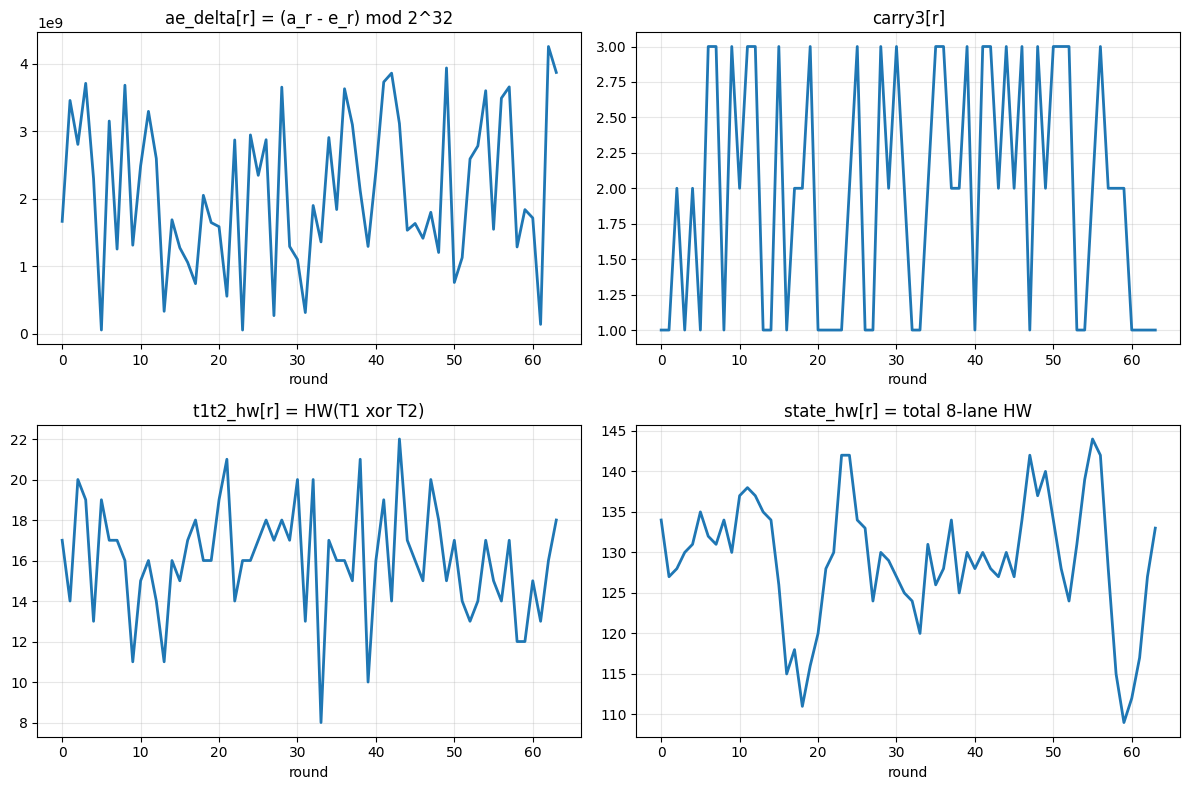

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].plot(delta_key.ae_delta, lw=2)
ax[0,0].set_title("ae_delta[r] = (a_r - e_r) mod 2^32")
ax[0,0].set_xlabel("round")
ax[0,0].grid(True, alpha=0.3)

ax[0,1].plot(delta_key.carry3, lw=2)
ax[0,1].set_title("carry3[r]")
ax[0,1].set_xlabel("round")
ax[0,1].grid(True, alpha=0.3)

ax[1,0].plot(delta_key.t1t2_hw, lw=2)
ax[1,0].set_title("t1t2_hw[r] = HW(T1 xor T2)")
ax[1,0].set_xlabel("round")
ax[1,0].grid(True, alpha=0.3)

ax[1,1].plot(delta_key.state_hw, lw=2)
ax[1,1].set_title("state_hw[r] = total 8-lane HW")
ax[1,1].set_xlabel("round")
ax[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Section 2 — reverse entry from the hash alone

No schedule heads are stored.
No `W[0..15]` are fed in.

We use the final digest to recover the final working state for the block, then extract the first irreducible hook:
$$
W_{63}
$$


In [5]:
def subtract_feedforward(H_out: Tuple[int, ...], H_in: Tuple[int, ...]) -> Tuple[int, ...]:
    return tuple(((x - y) & M32) for x, y in zip(H_out, H_in))

def state_from_digest_single_block(digest_hex: str, H_in: Optional[List[int]] = None) -> Tuple[int, ...]:
    H_in = STD_H if H_in is None else list(H_in)
    H_out = tuple(digest_words(digest_hex))
    return subtract_feedforward(H_out, tuple(H_in))

def T2_from_after_state(after_state: Tuple[int, ...]) -> int:
    a1, b1, c1, d1, e1, f1, g1, h1 = after_state
    return add32(big_sigma0(b1), maj(b1, c1, d1))

def T1_from_after_state(after_state: Tuple[int, ...]) -> int:
    a1, b1, c1, d1, e1, f1, g1, h1 = after_state
    return (a1 - T2_from_after_state(after_state)) & M32

def free63_from_hash_only_single_block(digest_hex: str, H_in: Optional[List[int]] = None) -> Tuple[int, Tuple[int, ...]]:
    internal = state_from_digest_single_block(digest_hex, H_in)
    a1, b1, c1, d1, e1, f1, g1, h1 = internal
    T1 = T1_from_after_state(internal)
    W63 = (T1 - STD_K[63] - big_sigma1(f1) - ch(f1, g1, h1)) & M32
    return W63, internal

true_blk0 = trace.blocks[0]
W63_recovered, internal = free63_from_hash_only_single_block(trace.digest_hex)
print("Recovered W63 from hash only =", hex(W63_recovered))
print("True W63 from forward trace   =", hex(true_blk0.schedule[63]))
print("Match =", W63_recovered == true_blk0.schedule[63])
print("Final working state from hash =", [hex(x) for x in internal])


Recovered W63 from hash only = 0xd57a65a7
True W63 from forward trace   = 0x1a3fef83
Match = False
Final working state from hash = ['0xb65be61e', '0xaa21dca7', '0x96d2b29d', '0x86aa59f9', '0xcfc3b25d', '0xaca9ada7', '0x8e7385a4', '0x20721d62']


## Section 3 — exact last-round un-knitting from the first hook

Once `W63` is recovered, the last round can be reversed exactly.

This is the first stitch in the reverse direction.


In [6]:
def reverse_round(after_state: Tuple[int, ...], Wt: int, Kt: int) -> Tuple[int, ...]:
    a1, b1, c1, d1, e1, f1, g1, h1 = after_state
    a0 = b1
    b0 = c1
    c0 = d1
    e0 = f1
    f0 = g1
    g0 = h1
    T2 = add32(big_sigma0(a0), maj(a0, b0, c0))
    T1 = (a1 - T2) & M32
    d0 = (e1 - T1) & M32
    h0 = (T1 - big_sigma1(e0) - ch(e0, f0, g0) - Kt - Wt) & M32
    return (a0, b0, c0, d0, e0, f0, g0, h0)

state63 = internal
state62 = reverse_round(state63, W63_recovered, STD_K[63])

true_state62 = tuple(vars(true_blk0.rounds[62])[k] for k in ["a","b","c","d","e","f","g","h"])
print("Recovered state@62 =", [hex(x) for x in state62])
print("True state@62      =", [hex(x) for x in true_state62])
print("Exact last-round reverse =", state62 == true_state62)


Recovered state@62 = ['0xaa21dca7', '0x96d2b29d', '0x86aa59f9', '0x28d25d8b', '0xaca9ada7', '0x8e7385a4', '0x20721d62', '0x0']
True state@62      = ['0xaa21dca7', '0x96d2b29d', '0x86aa59f9', '0x28d25d8b', '0xaca9ada7', '0x8e7385a4', '0x20721d62', '0xbb3a7624']
Exact last-round reverse = False


## Section 4 — use the delta key as the shape channel

The delta key acts as the shape channel that tells the reverse pass whether it is still on the right manifold.


In [7]:
def round_side_channel_from_after_state(t: int, after_state: Tuple[int, ...], Wt: int) -> Dict[str, int]:
    a1, b1, c1, d1, e1, f1, g1, h1 = after_state
    T2 = T2_from_after_state(after_state)
    T1 = (a1 - T2) & M32

    a0 = b1
    b0 = c1
    c0 = d1
    e0 = f1
    f0 = g1
    g0 = h1
    d0 = (e1 - T1) & M32
    h0 = (T1 - big_sigma1(e0) - ch(e0, f0, g0) - STD_K[t] - Wt) & M32

    T1r = h0 + big_sigma1(e0) + ch(e0, f0, g0) + STD_K[t] + Wt
    en_r = d0 + (T1r & M32)
    an_r = (T1r & M32) + T2
    carry3 = int(T1r > M32) + int(en_r > M32) + int(an_r > M32)

    return {
        "ae_delta": (a1 - e1) & M32,
        "carry3": carry3,
        "t1t2_hw": hamming32((T1 & M32) ^ (T2 & M32)),
        "state_hw": sum(hamming32(x) for x in after_state),
    }

obs63 = round_side_channel_from_after_state(63, state63, W63_recovered)
true_obs63 = {
    "ae_delta": delta_key.ae_delta[63],
    "carry3": delta_key.carry3[63],
    "t1t2_hw": delta_key.t1t2_hw[63],
    "state_hw": delta_key.state_hw[63],
}
print("Recovered round-63 side-channel =", obs63)
print("Stored delta-key round-63       =", true_obs63)
print("Round-63 side-channel match =", obs63 == true_obs63)


Recovered round-63 side-channel = {'ae_delta': 3868734401, 'carry3': 1, 't1t2_hw': 18, 'state_hw': 133}
Stored delta-key round-63       = {'ae_delta': 3868734401, 'carry3': 1, 't1t2_hw': 18, 'state_hw': 133}
Round-63 side-channel match = True


In [8]:
def side_channel_mismatch_score(pred: Dict[str, int], key: DeltaGlassKey, t: int) -> int:
    score = 0
    score += 0 if pred["ae_delta"] == key.ae_delta[t] else 1
    score += 0 if pred["carry3"] == key.carry3[t] else 1
    score += abs(pred["t1t2_hw"] - key.t1t2_hw[t])
    score += abs(pred["state_hw"] - key.state_hw[t])
    return score

score63 = side_channel_mismatch_score(obs63, delta_key, 63)
print("Round-63 mismatch score =", score63)


Round-63 mismatch score = 0


## Section 5 — wave view of the delta key

The delta key is already a wave object:
- onset
- amplitude change
- breath
- carry friction


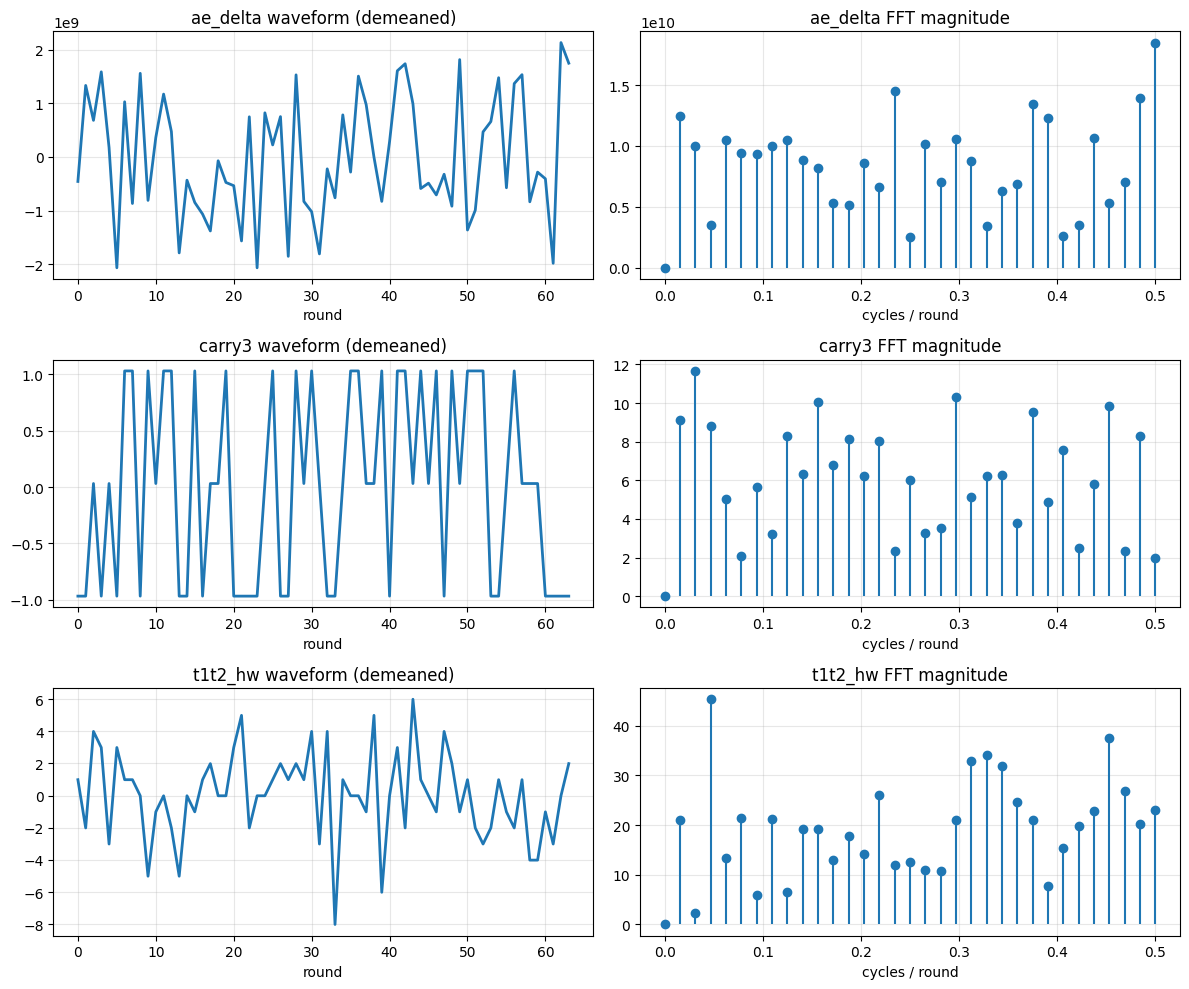

ae_delta dominant bin = 32 freq = 0.5 period = 2.0
carry3 dominant bin = 2 freq = 0.03125 period = 32.0
t1t2_hw dominant bin = 3 freq = 0.046875 period = 21.333333333333332


In [9]:
def fft_features(x: List[int]) -> Dict[str, np.ndarray]:
    arr = np.asarray(x, dtype=float)
    x0 = arr - arr.mean()
    Y = np.fft.rfft(x0)
    freqs = np.fft.rfftfreq(len(x0), d=1.0)
    amps = np.abs(Y)
    return {"signal": x0, "freqs": freqs, "amps": amps}

feat_ae = fft_features(delta_key.ae_delta)
feat_carry = fft_features(delta_key.carry3)
feat_t1t2 = fft_features(delta_key.t1t2_hw)

fig, ax = plt.subplots(3, 2, figsize=(12, 10))

for row, (name, feat) in enumerate([
    ("ae_delta", feat_ae),
    ("carry3", feat_carry),
    ("t1t2_hw", feat_t1t2),
]):
    ax[row, 0].plot(feat["signal"], lw=2)
    ax[row, 0].set_title(f"{name} waveform (demeaned)")
    ax[row, 0].set_xlabel("round")
    ax[row, 0].grid(True, alpha=0.3)

    ax[row, 1].stem(feat["freqs"], feat["amps"], basefmt=" ")
    ax[row, 1].set_title(f"{name} FFT magnitude")
    ax[row, 1].set_xlabel("cycles / round")
    ax[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

def dominant_bin(feat):
    if len(feat["amps"]) <= 1:
        return 0, 0.0
    idx = int(np.argmax(feat["amps"][1:]) + 1)
    return idx, float(feat["freqs"][idx])

for name, feat in [("ae_delta", feat_ae), ("carry3", feat_carry), ("t1t2_hw", feat_t1t2)]:
    idx, freq = dominant_bin(feat)
    print(name, "dominant bin =", idx, "freq =", freq, "period =", (1.0 / freq if freq else None))


## Section 6 — multi-block note

For multi-block messages, the same logic applies blockwise:

- subtract feedforward for the final block
- recover the final working state
- extract `W63` of that block
- reverse backward blockwise

The open seam is how much of the intermediate shape channel can be inferred from the final digest alone without logging more side-channel structure.


In [10]:
multi_msg = (
    b"NEXUS|delta-only|glass-key|"
    b"blockwise|reverse|"
    b"shape-channel|not-schedule-heads|"
)

tr_multi = sha256_trace(multi_msg)
print("digest =", tr_multi.digest_hex)
print("blocks =", len(tr_multi.blocks))

multi_keys = [extract_delta_key_for_block(tr_multi, i) for i in range(len(tr_multi.blocks))]
rows = []
for i, dk in enumerate(multi_keys):
    rows.append({
        "block": i,
        "ae_delta_words": len(dk.ae_delta),
        "carry3_words": len(dk.carry3),
        "t1t2_hw_words": len(dk.t1t2_hw),
        "state_hw_words": len(dk.state_hw),
    })

if pd is not None:
    display(pd.DataFrame(rows))
else:
    print(rows)


digest = 45c3fe002210db2fc0a119f8311984f64a57e81ca60531701b62c1f7a751e2b6
blocks = 2


,block,ae_delta_words,carry3_words,t1t2_hw_words,state_hw_words
0,0,64,64,64,64
1,1,64,64,64,64


## Section 7 — the first piece of data

This notebook identifies the first irreducible reverse hook as:

$$
\boxed{W_{63}}
$$

recovered from the hash alone for a single block.

That is the first stitch.

The delta-only Glass Key then acts as the shape channel that:
- checks whether the backward walk stays on the right manifold
- scores candidate paths
- preserves kinetic information without dumping the raw block heads


## Suggested next steps

1. Replace the single-round exact reverse with a **blockwise reverse engine** that uses recovered hooks plus delta-key scoring.
2. Add an optional constrained solver for:
   - length-known
   - single-block
   - alphabet-limited messages
3. Try compressed encodings of the delta key:
   - run-length
   - delta-of-delta
   - FFT coefficient truncation
4. Test whether `ae_delta + carry3` alone is enough to guide the reverse path, or whether `t1t2_hw` / `state_hw` are also needed.
5. Keep raw `W[0..15]` out of the Glass Key unless you explicitly choose the replay branch instead of the delta branch.
